In [53]:
import pandas as pd
import matplotlib.pyplot as plt

In [54]:
results1 = pd.read_csv('./evaluation_results/eval_results_2026-01-08_19-55-28.csv')
results2 = pd.read_csv('./evaluation_results/eval_results_2026-01-08_20-12-32.csv')
results3 = pd.read_csv('./evaluation_results/eval_results_2026-01-08_23-06-49.csv')

In [55]:
numerical_columns1 = results1.select_dtypes(include=['float64']).columns
print("dataset 1b:")
for column in numerical_columns1:
  print(f"Average {column}: {results1[column].mean()}")

print(f"\n")
numerical_columns2 = results2.select_dtypes(include=['float64']).columns
print("dataset 8b:")
for column in numerical_columns2:
  print(f"Average {column}: {results2[column].mean()}")


dataset 1b:
Average chunk_retrieval_time: 13.805541825294494
Average generation_time: 40.34670181274414
Average bleu: 0.0901934863201067
Average rouge: 0.25837673406948747
Average recall@k: 0.7
Average precision@k: 0.32


dataset 8b:
Average chunk_retrieval_time: 14.658889412879944
Average generation_time: 42.346356534957884
Average bleu: 0.08425314071761988
Average rouge: 0.23444266984852055
Average recall@k: 0.7
Average precision@k: 0.32


In [56]:
for i, row in results2.iterrows():
  print(f"question number {i}\n")
  print(f"Question: {row['question']}")
  print(f"ground truth: {row['ground_truth']}")
  print(f"generated answer: {row['model_output']}\n\n")
  print()

question number 0

Question: What is the tradeoff when using MD compared to RO?
ground truth: MD gives higher product quality with no additional post-treatment, but is very energy intensive and produces a small product flow. RO is more water-efficient and economically favorable but may require additional treatment to meet specifications.
generated answer: The answer is not supported by the provided document context. The given text discusses various aspects of a project in Zeeland, such as managing water levels and wetland development, but does not mention or compare any specific methods (MD vs RO) being used in that region.



question number 1

Question: What was the purpose of the trials conducted at Dow Terneuzen for the AquaSPICE project
ground truth: The purpose of the trials at Dow Terneuzen within the AquaSPICE project, is to research the potential of new technologies for reuse of cooling tower blowdown, to reduce freshwater intake at the I-Parc Dow Terneuzen site. 
generated an

In [57]:
import json

evaluation_questions_and_answers = json.loads(open("questions_answers_copy.json", "r", encoding="utf-8").read())
prepared_qa = []

for qa_pair in evaluation_questions_and_answers:
    prepared_qa.append({
        "question": qa_pair["question"]["nl"],
        "ground_truth": qa_pair["ground_truth"]["nl"],
        "project": qa_pair["project"],
        "language": "nl",
        "filename": qa_pair["filename"],
        "specificity": qa_pair["specificity"],
        "original_language": qa_pair["original_language"],
    })
    prepared_qa.append({
        "question": qa_pair["question"]["en"],
        "ground_truth": qa_pair["ground_truth"]["en"],
        "project": qa_pair["project"],
        "language": "en",
        "filename": qa_pair["filename"],
        "specificity": qa_pair["specificity"],
        "original_language": qa_pair["original_language"]
    })

for i, row in results1.iterrows():
    question = row["question"]
    
    matches = next((item for item in prepared_qa if item["question"] == question), None)
    if matches:
        results1.at[i, "original_language"] = matches["original_language"]
        results1.at[i, "specificity"] = matches["specificity"]
    else:
        print(f"No match found for question: {question}")

for i, row in results2.iterrows():
    question = row["question"]
    
    matches = next((item for item in prepared_qa if item["question"] == question), None)
    if matches:
        results2.at[i, "original_language"] = matches["original_language"]
        results2.at[i, "specificity"] = matches["specificity"]

    else:
        print(f"No match found for question: {question}")        



In [58]:
for results in [results1, results2, results3]:
  results['precision'] = results['precision'].apply(lambda x: float(str(x).strip("tensor([])")))
  results['recall'] = results['recall'].apply(lambda x: float(str(x).strip("tensor([])")))
  results['F1'] = results['F1'].apply(lambda x: float(str(x).strip("tensor([])")))
  results['total_time_taken'] = results['chunk_retrieval_time'] + results['generation_time']


In [59]:
numerical_columns = results1.select_dtypes(include=['float64']).columns

# Loop for rows where original_language is 'dutch'
print("Improvement factors for rows with original_language='dutch':")
for column in numerical_columns:
  dutch_rows1 = results1[results1['original_language'] == 'dutch']
  dutch_rows2 = results2[results2['original_language'] == 'dutch']
  original_avg = dutch_rows1[column].mean()
  new_avg = dutch_rows2[column].mean()
  improvement_factor = (new_avg - original_avg) / original_avg
  print(f"{column}: {original_avg:.4f},  {new_avg:.4f}, Improvement = {improvement_factor:.2%}")

print("\n")

# Loop for rows where original_language is 'english'
print("Improvement factors for rows with original_language='english':")
for column in numerical_columns:
  english_rows1 = results1[results1['original_language'] == 'english']
  english_rows2 = results2[results2['original_language'] == 'english']
  original_avg = english_rows1[column].mean()
  new_avg = english_rows2[column].mean()
  improvement_factor = (new_avg - original_avg) / original_avg
  print(f"{column}: {original_avg:.4f},  {new_avg:.4f}, Improvement = {improvement_factor:.2%}")

# Calculate the overall percentage improvement for selected metrics
metrics = ['bleu', 'rouge', 'precision', 'recall', 'F1']
total_original_avg = 0
total_new_avg = 0

for metric in metrics:
  original_avg = results1[metric].mean()
  new_avg = results2[metric].mean()
  total_original_avg += original_avg
  total_new_avg += new_avg

overall_improvement_factor = (total_new_avg - total_original_avg) / total_original_avg
print(f"Overall Improvement for selected metrics (bleu, rouge, precision, recall, F1): {overall_improvement_factor:.2%}")



Improvement factors for rows with original_language='dutch':
chunk_retrieval_time: 14.7351,  15.2695, Improvement = 3.63%
generation_time: 40.1238,  40.2427, Improvement = 0.30%
bleu: 0.0134,  0.0250, Improvement = 85.70%
rouge: 0.1081,  0.0913, Improvement = -15.58%
precision: 0.8336,  0.8225, Improvement = -1.33%
recall: 0.8314,  0.8292, Improvement = -0.26%
F1: 0.8323,  0.8257, Improvement = -0.80%
recall@k: 0.5000,  0.5000, Improvement = 0.00%
precision@k: 0.0000,  0.0000, Improvement = nan%
specificity: 7.5000,  7.5000, Improvement = 0.00%
total_time_taken: 54.8589,  55.5122, Improvement = 1.19%


Improvement factors for rows with original_language='english':
chunk_retrieval_time: 13.1858,  14.2518, Improvement = 8.08%
generation_time: 40.4953,  43.7488, Improvement = 8.03%
bleu: 0.1414,  0.1238, Improvement = -12.43%
rouge: 0.3585,  0.3299, Improvement = -7.99%
precision: 0.8731,  0.8704, Improvement = -0.31%
recall: 0.8740,  0.8675, Improvement = -0.74%
F1: 0.8735,  0.8689, Impr

C:\Users\erjbr\AppData\Local\Temp\ipykernel_22384\3236303486.py:10: RuntimeWarning: invalid value encountered in scalar divide
  improvement_factor = (new_avg - original_avg) / original_avg


In [60]:
results_dataframes = [results1, results2, results3]
averages_tables = {}

for idx, results in enumerate(results_dataframes, start=1):
  averages = results[['recall@k', 'precision@k', 'bleu', 'rouge', 'precision', 'recall', 'F1', 'total_time_taken']].mean()
  averages_table = pd.DataFrame([averages.round(2).values], columns=averages.index)
  averages_tables[f"results{idx}_averages"] = averages_table.style.format("{:.2f}").hide(axis="index")

rows = []

for idx, results in enumerate(results_dataframes, start=1):
    averages = results[['recall@k', 'precision@k', 'bleu', 'rouge',
                         'precision', 'recall', 'F1', 'total_time_taken']].mean()
    rows.append(averages)

combined_averages = pd.DataFrame(rows, index=[f"results{idx}" for idx in range(1, 4)])
combined_averages = combined_averages.round(2)
combined_averages

,recall@k,precision@k,bleu,rouge,precision,recall,F1,total_time_taken
results1,0.7,0.32,0.09,0.26,0.86,0.86,0.86,54.15
results2,0.7,0.32,0.08,0.23,0.85,0.85,0.85,57.01
results3,0.7,0.42,0.07,0.20,0.84,0.85,0.85,142.52


In [61]:
for idx, results in enumerate(results_dataframes, start=1):
  first_answer = results.iloc[9]['model_output']
  print(f"First generated answer for results{idx}: {first_answer}")
  print('')
  print('')
  print('___________________________________________')

First generated answer for results1: According to the provided context, the main goal of the NEREUS (New Energy and Resources from Urban Sanitation) Project is to recover valuable resources from domestic wastewater. The partners working on this project aimed to achieve this by adopting technologies that would enable a circular economy in the 2 Seas region.

The answer does not mention any specific details about how the freshwater canal will be designed within the Waterdunen project specifically, as it focuses primarily on the goals and objectives of the NEREUS Project.


___________________________________________
First generated answer for results2: The answer is not supported by the provided document context. The given text discusses various aspects of a project in Zeeland, such as managing water levels and wetland development, but does not mention or compare any specific design methods for freshwater canals being used at Dow Terneuzen for the AquaSPICE


____________________________

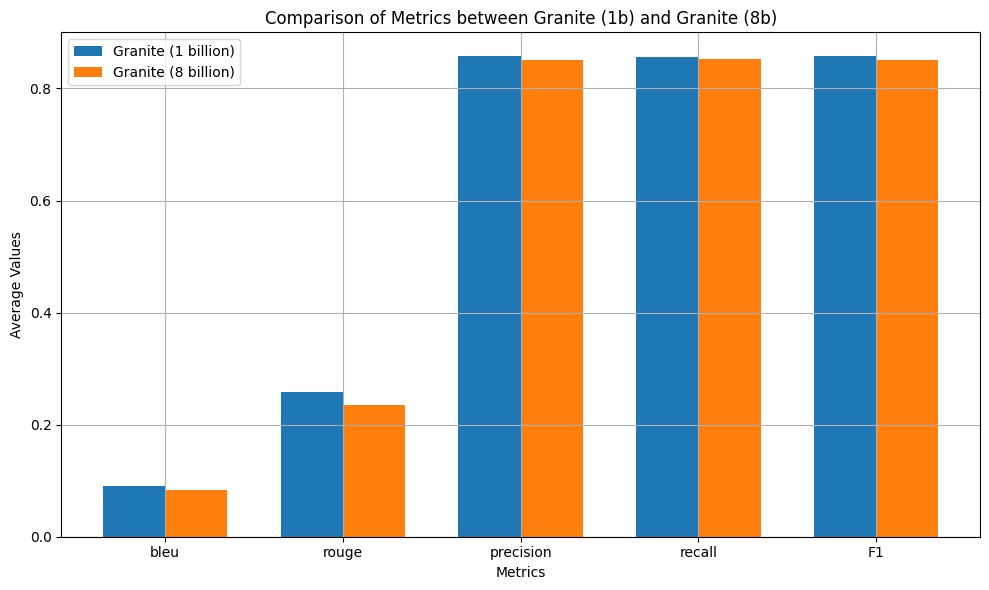

In [62]:
import numpy as np

metrics = ['bleu', 'rouge', 'precision', 'recall', 'F1']
results1_means = [results1[metric].apply(lambda x: x.item() if isinstance(x, pd.Series) else x).mean() for metric in metrics]
results2_means = [results2[metric].apply(lambda x: x.item() if isinstance(x, pd.Series) else x).mean() for metric in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, results1_means, width, label='Granite (1 billion)')
bars2 = ax.bar(x + width/2, results2_means, width, label='Granite (8 billion)')

ax.set_xlabel('Metrics')
ax.set_ylabel('Average Values')
ax.set_title('Comparison of Metrics between Granite (1b) and Granite (8b)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.tight_layout()
plt.grid()
plt.show()

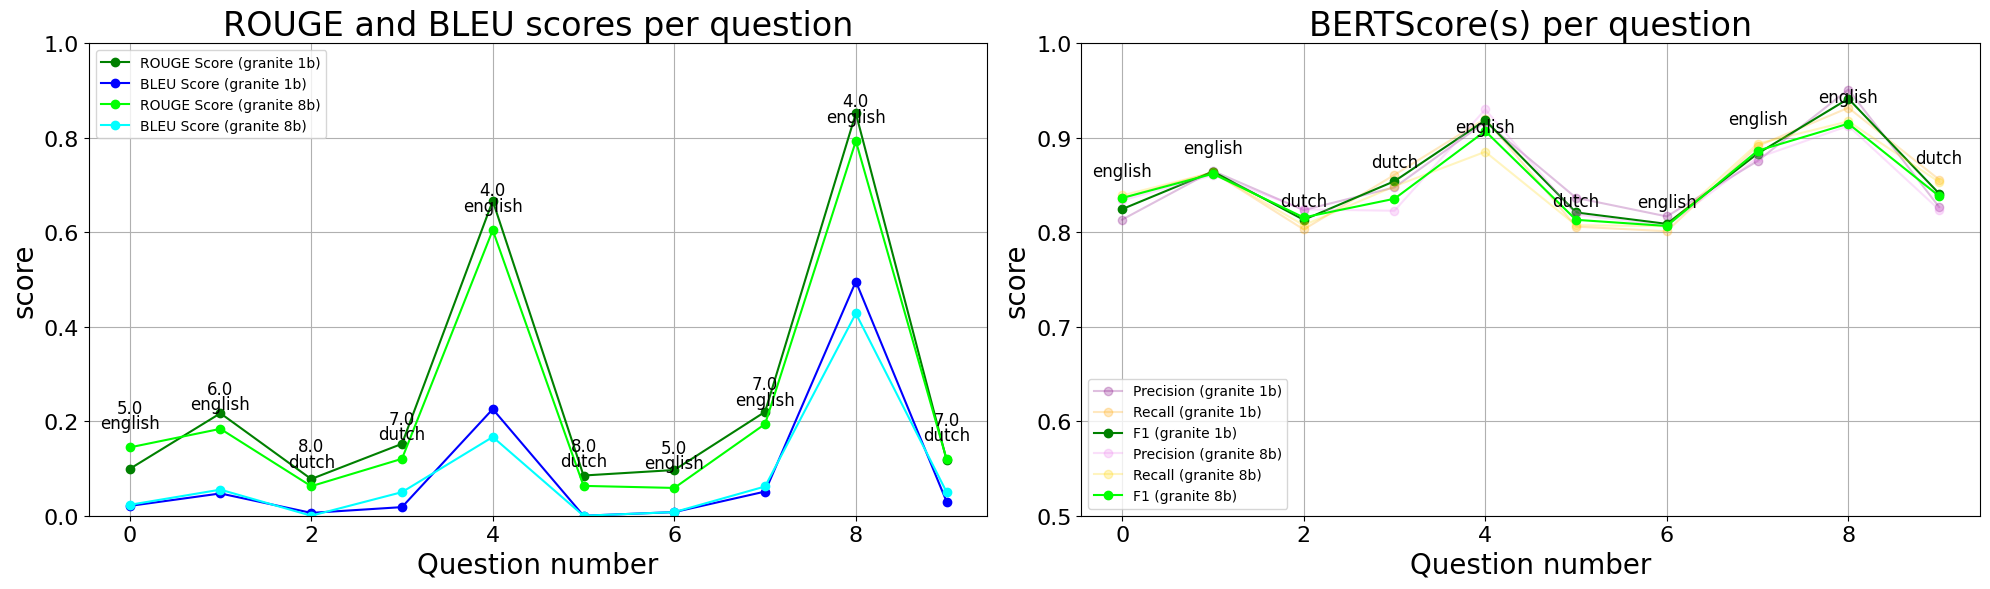

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Plot rouge and bleu scores for both results1 and results2
axes[0].plot(results1.index, results1['rouge'], marker='o', label='ROUGE Score (granite 1b)', color='green')
axes[0].plot(results1.index, results1['bleu'], marker='o', label='BLEU Score (granite 1b)', color='blue')
axes[0].plot(results2.index, results2['rouge'], marker='o', label='ROUGE Score (granite 8b)', color='lime')
axes[0].plot(results2.index, results2['bleu'], marker='o', label='BLEU Score (granite 8b)', color='cyan')
axes[0].set_title('ROUGE and BLEU scores per question', fontsize=24)
axes[0].set_xlabel('Question number', fontsize=20)
axes[0].tick_params(axis='x', labelsize=16)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].set_ylabel('score', fontsize=20)
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True)
for i, txt in enumerate(results2['original_language']):
  axes[0].annotate(txt, (results2.index[i], results2['rouge'][i]), textcoords="offset points", xytext=(0, 14), ha='center', fontsize=12)

for i, txt in enumerate(results2['specificity']):
  axes[0].annotate(txt, (results2.index[i], results2['rouge'][i]), textcoords="offset points", xytext=(0, 25), ha='center', fontsize=12)

# Plot precision, recall, and F1 scores for both results1 and results2
axes[1].plot(results1.index, results1['precision'], marker='o', label='Precision (granite 1b)', color='purple', alpha=0.25)
axes[1].plot(results1.index, results1['recall'], marker='o', label='Recall (granite 1b)', color='orange', alpha=0.25)
axes[1].plot(results1.index, results1['F1'], marker='o', label='F1 (granite 1b)', color='green')
axes[1].plot(results2.index, results2['precision'], marker='o', label='Precision (granite 8b)', color='violet', alpha=0.25)
axes[1].plot(results2.index, results2['recall'], marker='o', label='Recall (granite 8b)', color='gold', alpha=0.25)
axes[1].plot(results2.index, results2['F1'], marker='o', label='F1 (granite 8b)', color='lime')
axes[1].set_title('BERTScore(s) per question', fontsize=24)
axes[1].set_xlabel('Question number', fontsize=20)
axes[1].set_ylabel('score', fontsize=20)
axes[1].tick_params(axis='x', labelsize=16)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0.5, 1)
for i, txt in enumerate(results2['original_language']):
  axes[1].annotate(txt, (results2.index[i], results2['recall'][i]), textcoords="offset points", xytext=(0, 14), ha='center', fontsize=12)

plt.tight_layout()
plt.show()
